# Cell 1 - 資料載入與環境設定

## 功能說明
- 安裝必要套件：rioxarray、rasterstats、geopandas、python-dotenv
- 掛載 Google Drive 並載入所有分析所需資料
- 檢查資料檔案存在性與基本資訊

## 載入資料
- **河川資料**：riverpoly.shp（台灣河流線圖層）
- **避難所資料**：避難收容處所點位檔案v9.csv（全台避難所位置）
- **行政區資料**：TOWN_MOI_1140318.shp（鄉鎮市區界線）
- **地形資料**：dem_20m_hualien.tif（花蓮地區 20m 解析度 DEM）
- **環境設定**：.env（分析參數設定檔）

## 資料處理
- 將避難所經緯度轉為數值格式
- 顯示各圖層 CRS、筆數與範圍資訊
- 確保所有資料檔案可正常存取

## 輸出檢查
- 驗證所有檔案存在性
- 顯示資料基本統計資訊
- 確認 DEM 解析度與座標範圍

In [ ]:
!pip install -q rioxarray rasterstats geopandas
!pip install -q python-dotenv

from google.colab import drive
drive.mount('/content/drive')

import os
import rioxarray as rxr
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import pandas as pd


river_shp_path = "/content/drive/MyDrive/GIS_data/riverpoly/riverpoly.shp"
shelter_csv_path = "/content/drive/MyDrive/GIS_data/避難收容處所點位檔案v9.csv"
township_shp_path = "/content/drive/MyDrive/GIS_data/TOWN_MOI_1140318/TOWN_MOI_1140318.shp"
dem_path = "/content/drive/MyDrive/GIS_data/dem_20m_hualien.tif"
env_path = "/content/drive/MyDrive/Colab_Notebooks/RSGI/homework4/.env"

print("河川 shp 是否存在：", os.path.exists(river_shp_path))
print("避難所 csv 是否存在：", os.path.exists(shelter_csv_path))
print("鄉鎮 shp 是否存在：", os.path.exists(township_shp_path))
print("DEM tif 是否存在：", os.path.exists(dem_path))

rivers = gpd.read_file(river_shp_path)
print(f"\n河川資料載入完成，共 {len(rivers)} 筆")
print(f"河川 CRS: {rivers.crs}")

shelters_csv = pd.read_csv(shelter_csv_path)
print(f"\n避難所資料載入完成，共 {len(shelters_csv)} 筆")

shelters_csv["經度"] = pd.to_numeric(shelters_csv["經度"], errors="coerce")
shelters_csv["緯度"] = pd.to_numeric(shelters_csv["緯度"], errors="coerce")

townships = gpd.read_file(township_shp_path)
print(f"\n鄉鎮資料載入完成，共 {len(townships)} 筆")
print(f"鄉鎮 CRS: {townships.crs}")

dem = rxr.open_rasterio(dem_path, masked=True)
print("\nDEM 載入完成")
print(f"DEM shape: {dem.shape}")
print(f"DEM CRS: {dem.rio.crs}")
print(f"DEM bounds: {dem.rio.bounds()}")

# Cell 2 - 避難所資料清理與花蓮縣篩選

## 功能說明
- 從原始避難所 CSV 資料建立 GeoDataFrame
- 進行兩階段資料清理：座標範圍檢查與鄉鎮界線檢查
- 篩選花蓮縣避難所並輸出清理後資料

## 清理步驟
### 第一步：座標範圍檢查
- 移除空值、零值座標
- 限制在台灣合理範圍（經度 119~122，緯度 21~26）

### 第二步：鄉鎮界線檢查
- 使用 spatial join 檢查避難所是否在鄉鎮界線內
- 確保資料空間位置正確性

## 輸出結果
- **shelter_true**：全台清理後避難所資料
- **shelter_Hualien_true**：花蓮縣避難所資料
- **shelter_Hualien_true.csv**：花蓮縣避難所 CSV 檔案

## 資料統計
- 顯示清理前後筆數與移除原因分析
- 列出花蓮縣避難所涉及的鄉鎮市區
- 提供座標範圍與資料保留率資訊

In [ ]:
print("=== 避難所資料清理 ===")

# ===== 1. 重新建立避難所 GeoDataFrame（原始為經緯度 EPSG:4326）=====
shelters_original = gpd.GeoDataFrame(
    shelters_csv.copy(),
    geometry=gpd.points_from_xy(shelters_csv["經度"], shelters_csv["緯度"]),
    crs="EPSG:4326"
)

print(f"重新建立 GeoDataFrame，共 {len(shelters_original)} 筆")

original_count = len(shelters_original)

# ===== 2. 第一步：座標範圍檢查 =====
print("\n=== 第一步：座標範圍檢查 ===")

null_lon = shelters_original["經度"].isna().sum()
null_lat = shelters_original["緯度"].isna().sum()
zero_lon = (shelters_original["經度"] == 0).sum()
zero_lat = (shelters_original["緯度"] == 0).sum()

print(f"經度為空值: {null_lon} 筆")
print(f"緯度為空值: {null_lat} 筆")
print(f"經度為 0: {zero_lon} 筆")
print(f"緯度為 0: {zero_lat} 筆")

# 台灣合理範圍（經度 119~122，緯度 21~26）
out_of_range_condition = (
    (shelters_original["經度"] < 119) | (shelters_original["經度"] > 122) |
    (shelters_original["緯度"] < 21) | (shelters_original["緯度"] > 26)
)

out_of_range_count = out_of_range_condition.sum()
print(f"超出台灣範圍(經度119~122, 緯度21~26): {out_of_range_count} 筆")

range_clean_condition = (
    shelters_original["經度"].notna() &
    shelters_original["緯度"].notna() &
    (shelters_original["經度"] != 0) &
    (shelters_original["緯度"] != 0) &
    (shelters_original["經度"] >= 119) &
    (shelters_original["經度"] <= 122) &
    (shelters_original["緯度"] >= 21) &
    (shelters_original["緯度"] <= 26)
)

shelters_step1 = shelters_original[range_clean_condition].copy()
range_removed = original_count - len(shelters_step1)

print(f"座標範圍清理後剩餘: {len(shelters_step1)} 筆")
print(f"座標範圍移除: {range_removed} 筆")

# ===== 3. 第二步：鄉鎮界線檢查 =====
print("\n=== 第二步：鄉鎮界線檢查 ===")

# 先把避難所轉成與鄉鎮界線相同 CRS 再做 spatial join
if shelters_step1.crs != townships.crs:
    print("CRS 不一致，正在轉換為與鄉鎮資料一致...")
    shelters_step1 = shelters_step1.to_crs(townships.crs)

shelters_in_townships = gpd.sjoin(
    shelters_step1,
    townships,
    how="inner",
    predicate="within"
).copy()

township_removed = len(shelters_step1) - len(shelters_in_townships)

print(f"在鄉鎮界線內: {len(shelters_in_townships)} 筆")
print(f"不在鄉鎮界線內: {township_removed} 筆")

# ===== 4. 最終清理結果 =====
shelter_true = shelters_in_townships.copy()

# 移除 spatial join 產生的欄位
drop_cols = [col for col in ["index_right"] if col in shelter_true.columns]
if drop_cols:
    shelter_true = shelter_true.drop(columns=drop_cols)

final_count = len(shelter_true)
total_removed = original_count - final_count

print("\n=== 最終清理結果 ===")
print(f"清理前資料筆數: {original_count}")
print(f"清理後資料筆數: {final_count}")
print(f"總移除: {total_removed} 筆")
print(f"資料保留率: {final_count/original_count*100:.1f}%")

print("\n移除原因分析：")
print(f"- 座標範圍問題: {range_removed} 筆")
print(f"- 不在鄉鎮界線內: {township_removed} 筆")
print(f"- 總計: {total_removed} 筆")

print("\n清理後座標範圍:")
print(f"經度範圍: {shelter_true['經度'].min():.6f} ~ {shelter_true['經度'].max():.6f}")
print(f"緯度範圍: {shelter_true['緯度'].min():.6f} ~ {shelter_true['緯度'].max():.6f}")

# ===== 5. 篩選花蓮縣資料 =====
print("\n=== 篩選花蓮縣避難所 ===")

# 優先用 spatial join 後的縣市欄位 COUNTYNAME
if "COUNTYNAME" in shelter_true.columns:
    shelter_Hualien_true = shelter_true[shelter_true["COUNTYNAME"] == "花蓮縣"].copy()

# 若沒有 COUNTYNAME，再嘗試原始資料欄位
elif "縣市" in shelter_true.columns:
    shelter_Hualien_true = shelter_true[shelter_true["縣市"] == "花蓮縣"].copy()

else:
    raise KeyError("找不到可用的縣市欄位（COUNTYNAME 或 縣市）")

print(f"花蓮縣避難所筆數: {len(shelter_Hualien_true)}")

# 若有鄉鎮市區欄位，也順便列出前幾個鄉鎮
possible_town_cols = ["TOWNNAME", "鄉鎮市區"]
for col in possible_town_cols:
    if col in shelter_Hualien_true.columns:
        print(f"\n花蓮縣涉及的{col}：")
        print(sorted(shelter_Hualien_true[col].dropna().unique())[:20])
        break

# ===== 6. 建立 output 資料夾並輸出 CSV =====
output_dir = "/content/drive/MyDrive/Colab_Notebooks/RSGI/homework4/output"
os.makedirs(output_dir, exist_ok=True)

csv_path = f"{output_dir}/shelter_Hualien_true.csv"

# CSV 不適合直接存 geometry 物件，先轉成字串
shelter_Hualien_true_csv = shelter_Hualien_true.copy()
shelter_Hualien_true_csv["geometry"] = shelter_Hualien_true_csv["geometry"].astype(str)

shelter_Hualien_true_csv.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"\n已輸出 CSV：{csv_path}")

# ===== 7. 額外存成 GeoDataFrame 變數供後續分析 =====
# 後面若要做 buffer / DEM / zonal stats，建議直接用這個變數
print("\n=== shelter_Hualien_true 前五筆 ===")
display(shelter_Hualien_true.head())

# Cell 3 - 座標系統統一與花蓮縣資料預處理

## 功能說明
- 將所有圖層統一至 EPSG:3826 座標系統（TWD97）
- 針對花蓮縣進行資料預處理與裁切
- 建立花蓮縣邊界並裁切相關圖層

## 處理步驟
1. **座標系統統一**：將所有圖層轉換為 EPSG:3826
2. **建立花蓮縣邊界**：從行政區圖層提取花蓮縣範圍
3. **DEM 裁切**：依花蓮縣邊界裁切數值高程模型
4. **河流裁切**：提取花蓮縣內河流資料

## 處理圖層
- **shelter_true**：全台避難所點位
- **shelter_Hualien_true**：花蓮避難所點位
- **rivers**：全台河流
- **townships**：行政區界線
- **dem**：數值高程模型

## 輸出結果
- **Hualien_boundary**：花蓮縣邊界
- **dem_Hualien**：花蓮縣 DEM
- **rivers_Hualien**：花蓮縣河流

In [ ]:
# ---------------------------------------------------------
# 2. 投影至正確的CRS
# ---------------------------------------------------------


# CRS = 3826

target_crs = "EPSG:3826"

shelter_true = shelter_true.to_crs(target_crs)
shelter_Hualien_true = shelter_Hualien_true.to_crs(target_crs)
rivers = rivers.to_crs(target_crs)
townships = townships.to_crs(target_crs)
dem = dem.rio.reproject(target_crs)

print("shelter_true:", shelter_true.crs)
print("shelter_Hualien_true:", shelter_Hualien_true.crs)
print("rivers:", rivers.crs)
print("townships:", townships.crs)
print("dem:", dem.rio.crs)


# ---------------------------------------------------------
# 2. 建立花蓮縣邊界
# ---------------------------------------------------------
Hualien_boundary = townships[
    townships["COUNTYNAME"] == "花蓮縣"
].copy()

Hualien_boundary = Hualien_boundary.dissolve().reset_index(drop=True)

print("花蓮縣邊界建立完成")
display(Hualien_boundary.head())

# ---------------------------------------------------------
# 3. 裁切 DEM
# ---------------------------------------------------------
dem_Hualien = dem.rio.clip(
    Hualien_boundary.geometry,
    Hualien_boundary.crs,
    drop=True
)

print("DEM 裁切完成")
print("dem_Hualien shape:", dem_Hualien.shape)
print("dem_Hualien bounds:", dem_Hualien.rio.bounds())

# ---------------------------------------------------------
# 4. 裁切河流
# ---------------------------------------------------------
rivers_Hualien = gpd.clip(rivers, Hualien_boundary)
print("河流裁切完成，筆數：", len(rivers_Hualien))


# Cell 4 - 花蓮避難所地形分析

## 功能說明
- 使用 DEM 數值高程模型進行地形分析
- 為每個避難所建立 500m 緩衝區
- 計算緩衝區內的平均高程、高程標準差與最大坡度

## 資料來源
- **dem**：單波段 DEM（使用 rioxarray 載入）
- **shelter_Hualien_true**：避難所點位 GeoDataFrame
- **假設**：兩者已具相同座標系統，DEM 解析度為 20m

## 分析流程
1. 建立 500m 避難所緩衝區
2. 從 DEM 提取 2D 高程陣列
3. 計算坡度（以度為單位）
4. 顯示坡度統計摘要與視覺化圖表
5. 使用 zonal statistics 計算各緩衝區地形指標
6. 將分析結果加入 GeoDataFrame

## 輸出指標
- **mean_elev**：平均高程
- **std_elev**：高程標準差  
- **max_slope**：最大坡度

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray as rxr
from rasterstats import zonal_stats
from rasterio.transform import from_bounds
import rasterio

# ---------------------------------------------------------
# 1. Create 500 m shelter buffers from shelter_true
# ---------------------------------------------------------
shelter_Hualien_buffer_500m = shelter_Hualien_true.copy()
shelter_Hualien_buffer_500m["geometry"] = shelter_Hualien_buffer_500m.geometry.buffer(500)

print("500m shelter buffers created.")
print(f"Number of shelter buffers: {len(shelter_Hualien_buffer_500m)}")

# ---------------------------------------------------------
# 2. Extract 2D elevation array from DEM
# ---------------------------------------------------------
elevation = dem.values[0].astype("float64")

# Handle nodata safely
nodata = dem.rio.nodata
if nodata is not None:
    elevation[elevation == nodata] = np.nan

# ---------------------------------------------------------
# 3. Compute slope in degrees
# ---------------------------------------------------------
dy, dx = np.gradient(elevation, 20)  # 20 m pixel spacing
slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

# ---------------------------------------------------------
# 4. Print slope summary statistics
# ---------------------------------------------------------
slope_min = np.nanmin(slope_deg)
slope_max = np.nanmax(slope_deg)
slope_mean = np.nanmean(slope_deg)
slope_pct_gt30 = np.sum(slope_deg > 30) / np.sum(~np.isnan(slope_deg)) * 100

print("\n=== Slope Summary Statistics ===")
print(f"Minimum slope (deg): {slope_min:.2f}")
print(f"Maximum slope (deg): {slope_max:.2f}")
print(f"Mean slope (deg): {slope_mean:.2f}")
print(f"Percentage of pixels with slope > 30°: {slope_pct_gt30:.2f}%")

# ---------------------------------------------------------
# 5. Visualize elevation and slope
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(elevation, cmap="terrain")
axes[0].set_title("DEM Elevation")
axes[0].axis("off")
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label="Elevation")

im2 = axes[1].imshow(slope_deg, cmap="YlOrRd")
axes[1].set_title("Slope (degrees)")
axes[1].axis("off")
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label="Slope (deg)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. Prepare raster transform for zonal statistics
# ---------------------------------------------------------
height, width = elevation.shape
left, bottom, right, top = dem.rio.bounds()
transform = from_bounds(left, bottom, right, top, width, height)

# ---------------------------------------------------------
# 7. Zonal statistics: mean elevation and std elevation
# ---------------------------------------------------------
elev_stats = zonal_stats(
    shelter_Hualien_buffer_500m,
    elevation,
    affine=transform,
    stats=["mean", "std"],
    nodata=np.nan
)

# ---------------------------------------------------------
# 8. Zonal statistics: max slope
# ---------------------------------------------------------
slope_stats = zonal_stats(
    shelter_Hualien_buffer_500m,
    slope_deg,
    affine=transform,
    stats=["max"],
    nodata=np.nan
)

# ---------------------------------------------------------
# 9. Add zonal statistics back to GeoDataFrame
# ---------------------------------------------------------
shelter_Hualien_buffer_500m["mean_elev"] = [s["mean"] for s in elev_stats]
shelter_Hualien_buffer_500m["std_elev"] = [s["std"] for s in elev_stats]
shelter_Hualien_buffer_500m["max_slope"] = [s["max"] for s in slope_stats]

# ---------------------------------------------------------
# 10. Print first five rows
# ---------------------------------------------------------
print("\n=== Updated shelter_buffer_500m (first 5 rows) ===")
display(shelter_Hualien_buffer_500m.head())

print(shelter_Hualien_buffer_500m.columns.tolist())

# Cell 5 - 花蓮避難所初步地形資料整理與匯出

## 功能說明
- 從 `shelter_Hualien_buffer_500m` 中篩選必要欄位
- 保留基本資訊、地理位置與地形分析結果
- 匯出為 `shelter_Hualien_buffer_500.csv` 檔案

## 保留欄位
- **基本資訊**：序號、村里、地址、經緯度、處所名稱
- **收容資訊**：預計收容村里
- **幾何資訊**：geometry（座標資訊）
- **地形分析**：mean_elev（平均高程）、std_elev（高程標準差）、max_slope（最大坡度）

## 輸出檔案
- `shelter_Hualien_buffer_500.csv`：包含初步避難所資訊更新與地形分析結果





In [ ]:
# 只保留需要的欄位
cols_to_keep = [
    "序號",
    "村里",
    "避難收容處所地址",
    "經度",
    "緯度",
    "避難收容處所名稱",
    "預計收容村里",
    "geometry",
    "mean_elev",
    "std_elev",
    "max_slope"
]

shelter_Hualien_buffer_500m_export = shelter_Hualien_buffer_500m[
    [c for c in cols_to_keep if c in shelter_Hualien_buffer_500m.columns]
].copy()

print("保留後欄位：")
print(shelter_Hualien_buffer_500m_export.columns.tolist())

# 輸出 CSV
csv_path = f"{output_dir}/shelter_Hualien_buffer_500.csv"

export_df = shelter_Hualien_buffer_500m_export.copy()
export_df["geometry"] = export_df["geometry"].astype(str)

export_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"\nCSV 已輸出：{csv_path}")

display(shelter_Hualien_buffer_500m_export.head())

# Cell 6 - 花蓮河川風險緩衝區分析

## 功能說明
- 針對花蓮地區河川建立風險緩衝區
- 建立 0-500m 高風險區與 500-1000m 中風險區環帶
- 生成 `rivers_buffer` 圖層包含完整風險分區資訊

## 輸出圖層
- `rivers_buffer_500_diss`：0-500m 高風險區
- `rivers_ring_500_1000`：500-1000m 中風險環帶
- `rivers_buffer`：合併後的完整風險緩衝區

## 視覺化輸出
- 紅色區域：0-500m 高風險緩衝區
- 黃色區域：500-1000m 中風險環帶
- 黑色線條：河川位置



In [ ]:
from dotenv import load_dotenv
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. 讀取 .env
env_path = "/content/drive/MyDrive/Colab_Notebooks/RSGI/homework4/.env"
load_dotenv(env_path, override=True)

BUFFER_HIGH = int(os.getenv("BUFFER_HIGH"))
BUFFER_MID = int(os.getenv("BUFFER_MID"))

print(f"BUFFER_HIGH = {BUFFER_HIGH}")
print(f"BUFFER_MID = {BUFFER_MID}")
print(f"rivers_hualien CRS = {rivers_Hualien.crs}")

# 2. 建立 500m 完整 buffer（花蓮版河流）
rivers_buffer_500 = rivers_Hualien.copy()
rivers_buffer_500["geometry"] = rivers_buffer_500.geometry.buffer(BUFFER_HIGH)

# 3. 建立 1000m 完整 buffer（花蓮版河流）
rivers_buffer_1000 = rivers_Hualien.copy()
rivers_buffer_1000["geometry"] = rivers_buffer_1000.geometry.buffer(BUFFER_MID)

# 4. dissolve 成單一面
rivers_buffer_500_diss = rivers_buffer_500.dissolve().reset_index(drop=True)
rivers_buffer_500_diss["risk_zone"] = "high"
rivers_buffer_500_diss["dist_min"] = 0
rivers_buffer_500_diss["dist_max"] = BUFFER_HIGH

rivers_buffer_1000_diss = rivers_buffer_1000.dissolve().reset_index(drop=True)

# 5. 建立 500~1000m 環帶
rivers_ring_500_1000 = rivers_buffer_1000_diss.copy()
rivers_ring_500_1000["geometry"] = rivers_buffer_1000_diss.geometry.difference(
    rivers_buffer_500_diss.iloc[0].geometry
)
rivers_ring_500_1000["risk_zone"] = "mid"
rivers_ring_500_1000["dist_min"] = BUFFER_HIGH
rivers_ring_500_1000["dist_max"] = BUFFER_MID

# 6. 合併成最終 rivers_buffer
rivers_buffer = gpd.GeoDataFrame(
    pd.concat([rivers_buffer_500_diss, rivers_ring_500_1000], ignore_index=True),
    crs=rivers_Hualien.crs
)

print("rivers_buffer_500_diss 筆數:", len(rivers_buffer_500_diss))
print("rivers_ring_500_1000 筆數:", len(rivers_ring_500_1000))
print("rivers_buffer 筆數:", len(rivers_buffer))

display(rivers_buffer)

# 7. 畫圖確認（只顯示花蓮）
fig, ax = plt.subplots(figsize=(8, 10))

rivers_ring_500_1000.plot(
    ax=ax, color="yellow", edgecolor="orange", alpha=0.7, label="500–1000m"
)
rivers_buffer_500_diss.plot(
    ax=ax, color="red", edgecolor="darkred", alpha=0.5, label="0–500m"
)
rivers_Hualien.plot(
    ax=ax, color="black", linewidth=1, label="River"
)

# 若你前面已有花蓮縣邊界，建議加上
if "hualien_boundary" in globals():
    Hualien_boundary.boundary.plot(ax=ax, color="black", linewidth=1.2)
    xmin, ymin, xmax, ymax = Hualien_boundary.total_bounds
    pad = 2000
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)

ax.set_title("River Risk Buffers - Hualien County")
ax.set_aspect("equal")
ax.legend()
plt.show()

# Cell 7 - 花蓮避難所風險分析

## 功能說明
- 以 `shelter_Hualien_buffer_500` 為基底資料
- 計算避難所與河川距離分類（<500m, 500~1000m, >1000m）
- 結合坡度與高程資料進行風險評估
- 輸出 `shelter_Hualien_risk.csv` 包含完整風險分析結果

## 風險等級定義
- **low**：低風險
- **medium**：中等風險（距離河川1000m內且高程過低）
- **high**：高風險（距離河川500m內或坡度過陡）
- **extremely_high**：極高風險（距離河川500m內且坡度過陡）

In [ ]:
from dotenv import load_dotenv
import os
import numpy as np
import geopandas as gpd

# ---------------------------------------------------------
# 1. 讀取 .env 參數
# ---------------------------------------------------------
env_path = "/content/drive/MyDrive/Colab Notebooks/RSGI/homework4/.env"
load_dotenv(env_path, override=True)

slope_threshold_raw = os.getenv("SLOPE_THRESHOLD")
elevation_low_raw = os.getenv("ELEVATION_LOW")

print("SLOPE_THRESHOLD raw =", slope_threshold_raw)
print("ELEVATION_LOW raw =", elevation_low_raw)

if slope_threshold_raw is None or elevation_low_raw is None:
    raise ValueError("讀不到 SLOPE_THRESHOLD 或 ELEVATION_LOW，請檢查 .env")

SLOPE_THRESHOLD = float(slope_threshold_raw)
ELEVATION_LOW = float(elevation_low_raw)

print("SLOPE_THRESHOLD =", SLOPE_THRESHOLD)
print("ELEVATION_LOW =", ELEVATION_LOW)

# ---------------------------------------------------------
# 2. 以 shelter_Hualien_buffer_500 為基底複製新資料
# ---------------------------------------------------------
shelter_Hualien_risk = shelter_Hualien_buffer_500m_export.copy()

# ---------------------------------------------------------
# 3. 確保 CRS 都是 EPSG:3826
# ---------------------------------------------------------
target_crs = "EPSG:3826"

shelter_Hualien_true = shelter_Hualien_true.to_crs(target_crs)
rivers_buffer_500_diss = rivers_buffer_500_diss.to_crs(target_crs)
rivers_ring_500_1000 = rivers_ring_500_1000.to_crs(target_crs)

print("\nCRS 檢查：")
print("shelter_Hualien_true:", shelter_Hualien_true.crs)
print("rivers_buffer_500_diss:", rivers_buffer_500_diss.crs)
print("rivers_ring_500_1000:", rivers_ring_500_1000.crs)

# ---------------------------------------------------------
# 4. 用避難所點位判斷河川距離分類
# ---------------------------------------------------------
point_df = shelter_Hualien_true.copy().reset_index(drop=True)
point_df["__sid"] = point_df.index

shelter_Hualien_risk = shelter_Hualien_risk.reset_index(drop=True)
shelter_Hualien_risk["__sid"] = shelter_Hualien_risk.index

# 先建立三個輔助欄位
point_df["距離河川500m以內"] = 0
point_df["距離河川500-1000m"] = 0
point_df["距離河川超過1000m"] = 0

# 判斷 500m 內
join_high = gpd.sjoin(
    point_df[["__sid", "geometry"]],
    rivers_buffer_500_diss[["geometry"]],
    how="inner",
    predicate="within"
)
high_ids = set(join_high["__sid"].unique())
point_df.loc[point_df["__sid"].isin(high_ids), "距離河川500m以內"] = 1

# 判斷 500~1000m
join_mid = gpd.sjoin(
    point_df[["__sid", "geometry"]],
    rivers_ring_500_1000[["geometry"]],
    how="inner",
    predicate="within"
)
mid_ids = set(join_mid["__sid"].unique())
point_df.loc[point_df["__sid"].isin(mid_ids), "距離河川500-1000m"] = 1

# 其餘 >1000m
outside_mask = (
    (point_df["距離河川500m以內"] == 0) &
    (point_df["距離河川500-1000m"] == 0)
)
point_df.loc[outside_mask, "距離河川超過1000m"] = 1

# merge 回 risk 表
distance_cols = [
    "__sid",
    "距離河川500m以內",
    "距離河川500-1000m",
    "距離河川超過1000m"
]

shelter_Hualien_risk = shelter_Hualien_risk.merge(
    point_df[distance_cols],
    on="__sid",
    how="left"
)

# ---------------------------------------------------------
# 5. 整合成單一欄位 river_distance_category
# ---------------------------------------------------------
shelter_Hualien_risk["river_distance_category"] = ">1000m"

shelter_Hualien_risk.loc[
    shelter_Hualien_risk["距離河川500-1000m"] == 1,
    "river_distance_category"
] = "500~1000m"

shelter_Hualien_risk.loc[
    shelter_Hualien_risk["距離河川500m以內"] == 1,
    "river_distance_category"
] = "<500m"

# ---------------------------------------------------------
# 6. 若高程/坡度缺值，先補安全值避免誤判
# ---------------------------------------------------------
shelter_Hualien_risk["max_slope"] = shelter_Hualien_risk["max_slope"].fillna(-9999)
shelter_Hualien_risk["mean_elev"] = shelter_Hualien_risk["mean_elev"].fillna(999999)

# ---------------------------------------------------------
# 7. 建立風險等級條件
# ---------------------------------------------------------
cond_lt_500 = shelter_Hualien_risk["river_distance_category"] == "<500m"
cond_lt_1000 = shelter_Hualien_risk["river_distance_category"].isin(["<500m", "500~1000m"])
cond_steep = shelter_Hualien_risk["max_slope"] > SLOPE_THRESHOLD
cond_low_elev = shelter_Hualien_risk["mean_elev"] < ELEVATION_LOW

# ---------------------------------------------------------
# 8. 新增風險等級欄位
# ---------------------------------------------------------
shelter_Hualien_risk["risk_level"] = "low"

shelter_Hualien_risk.loc[
    cond_lt_1000 & cond_low_elev,
    "risk_level"
] = "medium"

shelter_Hualien_risk.loc[
    cond_lt_500 | cond_steep,
    "risk_level"
] = "high"

shelter_Hualien_risk.loc[
    cond_lt_500 & cond_steep,
    "risk_level"
] = "extremely_high"

# ---------------------------------------------------------
# 9. 清理暫時欄位
# 如果你只想保留 river_distance_category，
# 就把三個輔助欄位一起刪掉
# ---------------------------------------------------------
shelter_Hualien_risk = shelter_Hualien_risk.drop(
    columns=[
        "__sid",
        "距離河川500m以內",
        "距離河川500-1000m",
        "距離河川超過1000m"
    ]
)

# ---------------------------------------------------------
# 10. 檢查結果
# ---------------------------------------------------------
print("\nriver_distance_category 統計：")
print(shelter_Hualien_risk["river_distance_category"].value_counts(dropna=False))

print("\n風險等級統計：")
print(shelter_Hualien_risk["risk_level"].value_counts(dropna=False))

print("\n前五筆資料：")
display(shelter_Hualien_risk.head())

# ---------------------------------------------------------
# 11. 輸出新檔案：shelter_Hualien_risk.csv
# ---------------------------------------------------------
csv_path = f"{output_dir}/shelter_Hualien_risk.csv"

export_df = shelter_Hualien_risk.copy()
export_df["geometry"] = export_df["geometry"].astype(str)

export_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"\nCSV 已輸出：{csv_path}")

# Cell 8 - 花蓮縣地形陰影圖與避難所風險視覺化

## 功能說明
- 結合 DEM 地形陰影、河川緩衝區與避難所風險等級
- 建立綜合性風險地圖，直觀展示花蓮縣避難所分布與風險狀況

## 圖層內容
- **地形背景**：DEM hillshade（光源方位315°，高度45°）
- **河川緩衝區**：
  - 灰色區域：500-1000m 中風險緩衝區
  - 淺藍色區域：<500m 高風險緩衝區
- **河川線條**：深藍色河流位置
- **避難所風險點**：
  - 深紅色：極高風險
  - 橙色：高風險
  - 金色：中等風險
  - 綠色：低風險

## 視覺化特色
- 使用地形陰影增強立體感
- 自訂圖例包含所有圖層說明
- 標註座標系統資訊（EPSG:3826）
- 高解析度輸出（300 DPI）

## 輸出檔案
- `Hualien_dem_hillshade_river_buffer_shelter_risk.png`：完整風險地圖

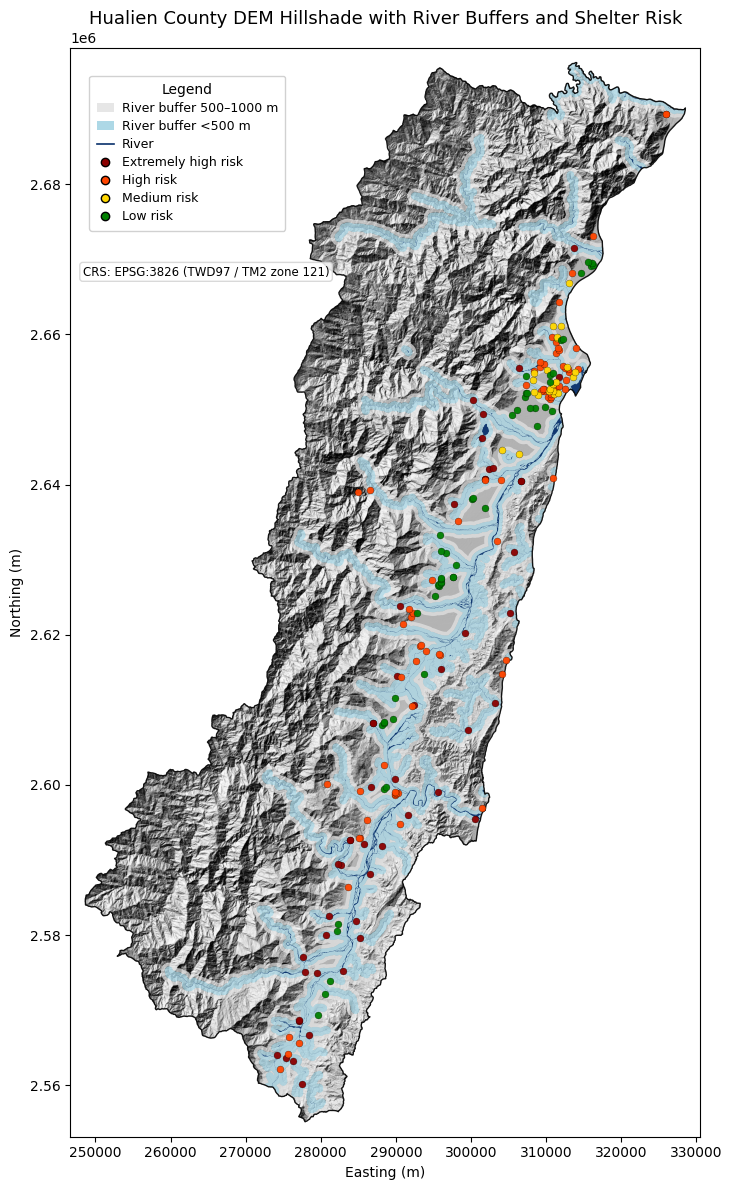

Figure exported: /content/drive/MyDrive/Colab_Notebooks/RSGI/homework4/output/Hualien_terrain_risk_map.png


In [96]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---------------------------------------------------------
# 1. Standardize CRS
# ---------------------------------------------------------
target_crs = dem.rio.crs

shelter_plot = shelter_Hualien_risk.to_crs(target_crs).copy()
hualien_boundary = Hualien_boundary.to_crs(target_crs)

# Clip rivers and river buffers to Hualien boundary
river_line = gpd.clip(rivers.to_crs(target_crs), hualien_boundary)
river_500 = gpd.clip(rivers_buffer_500_diss.to_crs(target_crs), hualien_boundary)
river_500_1000 = gpd.clip(rivers_ring_500_1000.to_crs(target_crs), hualien_boundary)

# ---------------------------------------------------------
# 2. Use existing English risk column
# ---------------------------------------------------------
risk_column = "risk_level"

# ---------------------------------------------------------
# 3. Get Hualien extent
# ---------------------------------------------------------
xmin, ymin, xmax, ymax = hualien_boundary.total_bounds
pad = 2000
xmin -= pad
ymin -= pad
xmax += pad
ymax += pad

# ---------------------------------------------------------
# 4. Prepare DEM and hillshade
# ---------------------------------------------------------
elevation = dem.values[0].astype("float64")

nodata = dem.rio.nodata
if nodata is not None:
    elevation[elevation == nodata] = np.nan

left, bottom, right, top = dem.rio.bounds()
extent = [left, right, bottom, top]

ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(elevation, vert_exag=1, dx=20, dy=20)

# ---------------------------------------------------------
# 5. Risk colors
# ---------------------------------------------------------
risk_color_map = {
    "extremely_high": "#8B0000",
    "high": "#FF4500",
    "medium": "#FFD700",
    "low": "#008000"
}

# ---------------------------------------------------------
# 6. Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 12))

# Hillshade background
ax.imshow(
    hillshade,
    cmap="gray",
    extent=extent,
    origin="upper",
    alpha=1.0
)

# River buffer: 500–1000 m
river_500_1000.plot(
    ax=ax,
    color="#E6E6E6",
    edgecolor="none",
    alpha=0.7
)

# River buffer: <500 m
river_500.plot(
    ax=ax,
    color="#ADD8E6",
    edgecolor="none",
    alpha=0.8
)

# River line
river_line.plot(
    ax=ax,
    color="#08306B",
    linewidth=0.7,
    alpha=0.95
)

# Hualien boundary
hualien_boundary.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.0,
    alpha=0.9
)

# Shelter risk points (convert buffer polygons to centroids)
shelter_plot_points = shelter_plot.copy()
shelter_plot_points["geometry"] = shelter_plot_points.geometry.centroid

for risk_level, color in risk_color_map.items():
    subset = shelter_plot_points[shelter_plot_points[risk_column] == risk_level]
    if len(subset) > 0:
        subset.plot(
            ax=ax,
            markersize=25,
            color=color,
            edgecolor="black",
            linewidth=0.2,
            alpha=0.95,
            zorder=20
        )

# ---------------------------------------------------------
# 7. Display extent
# ---------------------------------------------------------
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# ---------------------------------------------------------
# 8. Custom legend
# ---------------------------------------------------------
legend_elements = [
    Patch(facecolor="#E6E6E6", edgecolor="none", label="River buffer 500–1000 m"),
    Patch(facecolor="#ADD8E6", edgecolor="none", label="River buffer <500 m"),
    Line2D([0], [0], color="#08306B", lw=1.2, label="River"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#8B0000", markeredgecolor="black", markersize=6, label="Extremely high risk"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#FF4500", markeredgecolor="black", markersize=6, label="High risk"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#FFD700", markeredgecolor="black", markersize=6, label="Medium risk"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#008000", markeredgecolor="black", markersize=6, label="Low risk"),
]

ax.legend(
    handles=legend_elements,
    title="Legend",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    fontsize=9,
    title_fontsize=10,
    borderpad=0.6,
    labelspacing=0.4,
    handlelength=1.4,
    handletextpad=0.6
)

# CRS note below legend
ax.text(
    0.02, 0.80,
    "CRS: EPSG:3826 (TWD97 / TM2 zone 121)",
    transform=ax.transAxes,
    fontsize=8.5,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="lightgray", boxstyle="round,pad=0.25")
)

# ---------------------------------------------------------
# 9. Figure settings
# ---------------------------------------------------------
ax.set_title("Hualien County DEM Hillshade with River Buffers and Shelter Risk", fontsize=13)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 10. Save figure
# ---------------------------------------------------------
img_path = f"{output_dir}/Hualien_terrain_risk_map.png"
fig.savefig(img_path, dpi=300, bbox_inches="tight")
print(f"Figure exported: {img_path}")

# Cell 9 - .json檔案輸出

1. 從 `shelter_Hualien_risk` 擷取避難所風險稽核所需欄位。
2. 將欄位整理為標準輸出格式：
   - `shelter_id`
   - `name`
   - `risk_level`
   - `mean_elevation`
   - `max_slope`
3. 輸出為 `terrain_risk_audit.json`，作為後續檢核與資料交換使用。

In [ ]:
import json
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. 複製資料
# ---------------------------------------------------------
audit_df = shelter_Hualien_risk.copy()

# ---------------------------------------------------------
# 2. 選取並重新命名欄位
# 依你目前資料欄位調整：
# - 序號 -> shelter_id
# - 避難收容處所名稱 -> name
# - risk level -> risk_level
# - mean_elev -> mean_elevation
# - max_slope -> max_slope
# ---------------------------------------------------------
audit_df = audit_df[[
    "序號",
    "避難收容處所名稱",
    "risk_level",
    "mean_elev",
    "max_slope"
]].rename(columns={
    "序號": "shelter_id",
    "避難收容處所名稱": "name",
    "mean_elev": "mean_elevation",
    "max_slope": "max_slope"
})

# ---------------------------------------------------------
# 3. 處理 NaN，避免 JSON 出現非標準值
# ---------------------------------------------------------
audit_df = audit_df.replace({np.nan: None})

# ---------------------------------------------------------
# 4. 轉成 list of dict
# ---------------------------------------------------------
audit_records = audit_df.to_dict(orient="records")

# ---------------------------------------------------------
# 5. 輸出 JSON
# ---------------------------------------------------------
json_path = f"{output_dir}/terrain_risk_audit.json"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(audit_records, f, ensure_ascii=False, indent=2)

print(f"JSON exported: {json_path}")

# ---------------------------------------------------------
# 6. 預覽前 5 筆
# ---------------------------------------------------------
print("\nPreview:")
print(json.dumps(audit_records[:5], ensure_ascii=False, indent=2))

# Cell 10 - Top 10 極高風險避難所分組柱狀圖

## 功能說明
- 分析極高風險避難所的地形特徵
- 依最大坡度排序，取前10名進行視覺化
- 同時顯示坡度與平均高程的雙指標對比

## 資料來源
- **shelter_Hualien_risk**：風險分析結果表
- **terrain_risk_audit.json**：避難所稽核記錄檔案
- 篩選條件：risk_level = "extremely_high"

## 圖表特色
- **分組柱狀圖**：每個避難所顯示兩個指標
  - 深紅色柱：最大坡度（度）
  - 藍色柱：平均高程（公尺）
- **數值標籤**：每個柱頂顯示具體數值（小數點一位）
- **X軸標籤**：使用 shelter_id 作為識別碼

## 視覺化目的
- 識別最具風險的避難所位置
- 比較坡度與高程兩個關鍵風險因子
- 提供決策者直觀的風險排序依據

## 輸出檔案
- `top10_extremely_high_grouped_bar_chart.png`：高解析度分組柱狀圖

Extremely high-risk shelters count: 51

Top 10 extremely high-risk shelters:


,序號,避難收容處所名稱,risk_level,mean_elev,max_slope,shelter_id
0,3437,富世活動中心,extremely_high,87.577001,70.428532,3437
1,1883,奇美社區活動中心,extremely_high,63.718883,66.628512,1883
2,2950,銅門收容所,extremely_high,179.414936,65.691610,2950
3,2333,磯崎村辦公處活動中心,extremely_high,83.961822,63.652254,2333
4,1555,樂合社區活動中心,extremely_high,188.470148,62.642926,1555
5,2357,森榮里辦公處,extremely_high,210.267068,61.390305,2357
6,2130,豐濱國中禮堂,extremely_high,36.283165,57.256419,2130
7,1528,卓樂社區活動中心,extremely_high,231.148161,57.183616,1528
8,1778,靜浦國小大禮堂,extremely_high,18.596167,54.610344,1778
9,2047,八里灣基督長老教會,extremely_high,108.427557,54.414001,2047


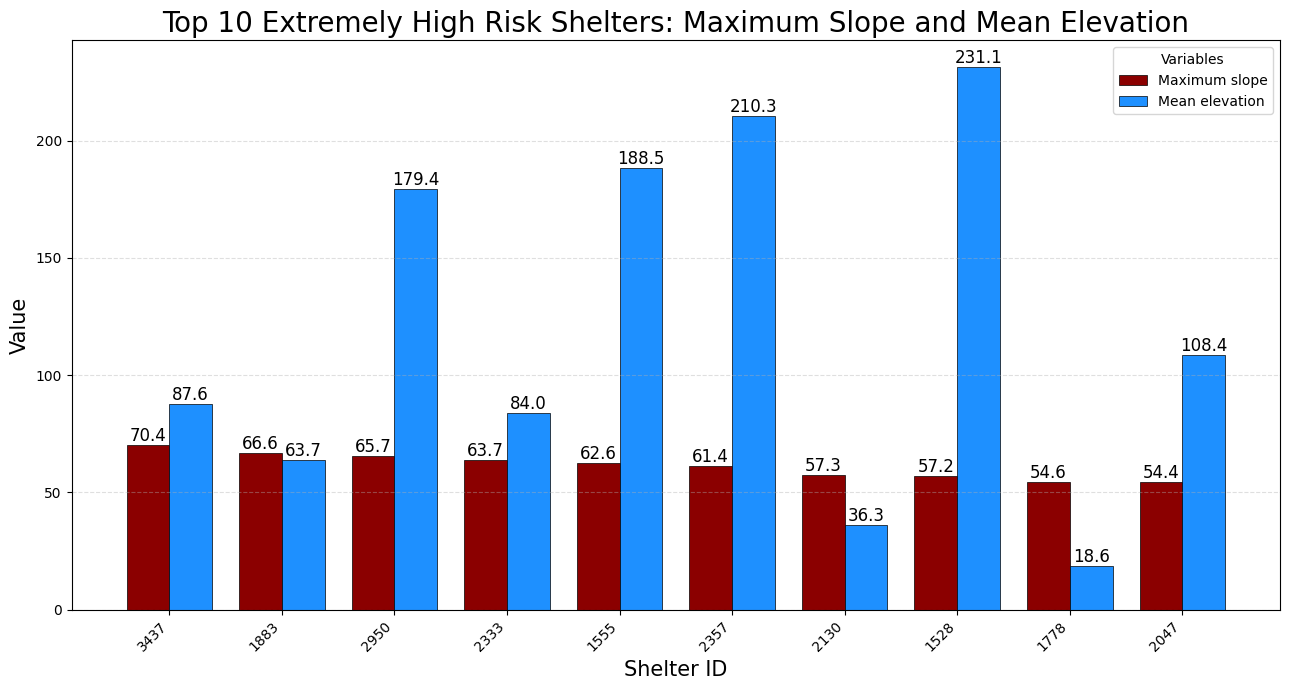

Figure exported: /content/drive/MyDrive/Colab_Notebooks/RSGI/homework4/output/top10_risk_shelters_bar_chart.png


In [98]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Read main table
# ---------------------------------------------------------
plot_df = shelter_Hualien_risk.copy()

# ---------------------------------------------------------
# 2. Read JSON audit file
# ---------------------------------------------------------
json_path = f"{output_dir}/terrain_risk_audit.json"

with open(json_path, "r", encoding="utf-8") as f:
    audit_data = json.load(f)

audit_df = pd.DataFrame(audit_data)

# ---------------------------------------------------------
# 3. Set risk column
# ---------------------------------------------------------
risk_column = "risk_level"

# ---------------------------------------------------------
# 4. Filter extremely high risk only
# ---------------------------------------------------------
extreme_df = plot_df[
    plot_df[risk_column] == "extremely_high"
].copy()

extreme_df = extreme_df.dropna(subset=["mean_elev", "max_slope"])

print("Extremely high-risk shelters count:", len(extreme_df))

# ---------------------------------------------------------
# 5. Top 10 by max_slope
# ---------------------------------------------------------
top10_df = extreme_df.sort_values(
    by="max_slope",
    ascending=False
).head(10).copy()

# ---------------------------------------------------------
# 6. Merge shelter_id from JSON
# ---------------------------------------------------------
audit_df["shelter_id"] = audit_df["shelter_id"].astype(str)
top10_df["序號"] = top10_df["序號"].astype(str)

top10_df = top10_df.merge(
    audit_df[["shelter_id"]],
    left_on="序號",
    right_on="shelter_id",
    how="left"
)

top10_df["shelter_id"] = top10_df["shelter_id"].fillna(top10_df["序號"])

print("\nTop 10 extremely high-risk shelters:")
display(top10_df[[
    "序號",
    "避難收容處所名稱",
    risk_column,
    "mean_elev",
    "max_slope",
    "shelter_id"
]])

# ---------------------------------------------------------
# 7. Plot grouped bars
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(top10_df))
width = 0.38

bars_slope = ax.bar(
    x - width/2,
    top10_df["max_slope"],
    width=width,
    color="#8B0000",
    edgecolor="black",
    linewidth=0.5,
    label="Maximum slope"
)

bars_elev = ax.bar(
    x + width/2,
    top10_df["mean_elev"],
    width=width,
    color="#1E90FF",
    edgecolor="black",
    linewidth=0.5,
    label="Mean elevation"
)

# ---------------------------------------------------------
# 8. Add value labels
# ---------------------------------------------------------
for bar in bars_slope:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

for bar in bars_elev:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

# ---------------------------------------------------------
# 9. Labels and style
# ---------------------------------------------------------
ax.set_title("Top 10 Extremely High Risk Shelters: Maximum Slope and Mean Elevation", fontsize=20)
ax.set_xlabel("Shelter ID", fontsize=15)
ax.set_ylabel("Value", fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(top10_df["shelter_id"], rotation=45, ha="right")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Variables", loc="upper right")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 10. Save figure
# ---------------------------------------------------------
img_path = f"{output_dir}/top10_risk_shelters_bar_chart.png"
fig.savefig(img_path, dpi=300, bbox_inches="tight")
print(f"Figure exported: {img_path}")